# 📷 얼굴 사진으로 외모상 연령대 추정하기

**실제 사진 6장 → Decisions API → 연령대·선택 확률·사진별 응답 시간**

`data/age_faces`에 **촬영 당시 7세 어린이·10대·20대·30대·40대·50대** 인물 사진을 한 장씩 준비했습니다. 사진을 따로 구하지 않아도 위에서 아래로 바로 실행할 수 있습니다.

결과는 **외모상 연령대 추정**이며 실제 나이 확인이 아닙니다. 조명·화장·표정·보정에 따라 달라집니다. 성인 인증이나 서비스 이용 자격 판단용으로 사용하지 않습니다.

사진은 공개 라이선스/퍼블릭 도메인 자료입니다. 출처·저작자·촬영일·참고 나이는 [사진 출처](data/age_faces/출처.md)에 기록했습니다. 유명인 사진이므로 모델의 기존 지식이 영향을 줄 수 있어 정확도 벤치마크로 해석하지 않습니다.

이 노트북에는 **설정 → 사진 보기 → API 함수 → 6장 분류 → 평균 시간·비용 확인**만 담았습니다. `raise`나 `try/except` 없이 읽기 쉽게 작성했습니다.

## 1. 준비

`부록` 폴더에서 `uv sync`로 환경을 구축합니다. 노트북 커널은 `부록/.venv`의 Python을 선택하세요.

현재 폴더의 `.env`에서 `OPENAI_API_KEY`를 한 번 읽습니다. 사진은 OpenAI로 전송됩니다. OpenAI 공식 SDK를 직접 사용합니다.

In [1]:
import io
import json
import time
import base64
from pathlib import Path

import pandas as pd
from PIL import Image, ImageOps
from dotenv import load_dotenv
from openai import OpenAI
from IPython.display import display

# 부록 폴더에서 실행합니다.
folder = Path.cwd()
data = folder / "data" / "age_faces"
output = folder / "output" / "age_faces"
output.mkdir(parents=True, exist_ok=True)
# 현재 폴더의 API 키를 읽습니다. 키는 출력하지 않습니다.
load_dotenv(".env")
client = OpenAI(timeout=30, max_retries=0)
USD_PER_MILLION_TOKENS = 0.10  # 기본 입력 토큰 요금
KRW_PER_USD = 1500  # 실시간 환율이 아닌 가정값

# 출처 파일에서 사진 목록만 읽습니다. 이름과 참고 나이는 API에 보내지 않습니다.
samples = pd.read_json(data / "samples.json")
image_paths = [data / name for name in samples["file"]]
print("실습 사진:", len(image_paths), "장")


실습 사진: 6 장


## 2. 준비된 얼굴 사진 보기

파일명을 `sample_01`처럼 중립적으로 정했습니다. **사람의 이름·촬영일·참고 나이는 모델에 보내지 않습니다.** 3절은 준비된 JPEG 샘플을 그대로 전송합니다. 4절의 함수에서는 JPEG 입력을 새로 만들어 원본 사진의 EXIF 정보를 제외합니다.

참고 연령대는 출처에 명시된 당시 나이 또는 촬영일과 공개된 생년월일로 계산한 나이에 따른 것입니다. 이것과 모델이 판단하는 ‘외모상 나이’는 같은 개념이 아닙니다.

In [2]:
display(samples[["file", "age_at_photo", "reference_group"]].rename(
    columns={"file": "사진", "age_at_photo": "촬영 당시 나이", "reference_group": "참고 연령대"}))
# 사진은 아래 분류 셀에서 추정 결과와 함께 표시합니다.


,사진,촬영 당시 나이,참고 연령대
0,sample_00.jpg,7,10세 미만
1,sample_01.jpg,16,10대
2,sample_02.png,25,20대
3,sample_03.jpg,31,30대
4,sample_04.jpg,49,40대
5,sample_05.png,51,50대


## 3. 연령대 선택지

`choice`는 주어진 선택지 중 하나를 고르는 질문입니다. 10대~50대만 넣어 범위 밖 사진을 억지로 분류하지 않도록 **10세 미만·60대 이상·판단 어려움**도 넣습니다.

얼굴이 불분명하거나 사람이 여럿이면 ‘판단 어려움’을 선택하도록 요청합니다. API 자체가 판단을 거절할 수도 있습니다.

In [3]:
AGE_GROUPS = ["10세 미만", "10대", "20대", "30대", "40대", "50대", "60대 이상", "판단 어려움"]
# choice 질문은 아래 연령대 선택지 중 하나를 반환합니다.
QUESTION = {
    "type": "choice",
    "name": "apparent_age_group",
    "instructions": (
        "얼굴의 시각적 특징만으로 사진 속 한 사람의 외모상 연령대를 추정하세요. "
        "10대는 10~19세, 20대는 20~29세처럼 해석합니다. "
        "유명인을 알아보더라도 그 사람의 이름, 현재 나이, 알려진 생년월일을 근거로 답하지 마세요. "
        "여러 사람이 있거나 얼굴이 불분명하거나 근거가 부족하면 판단 어려움을 선택하세요."
    ),
    "choices": [{"value": group} for group in AGE_GROUPS],
}


### 한 장으로 핵심 API 실행해 보기

첫 번째 어린이 사진 한 장을 그대로 보내 API의 기본 구조를 확인합니다.

- `input`: 모델이 볼 사진과 요청 문장입니다.
- `questions=[QUESTION]`: 앞에서 정의한 연령대 선택지와 판단 기준입니다.
- `result.answers[0]`: 추정 연령대와 선택지별 확률이 담긴 응답입니다.

`probabilities`는 선택지별 확률 분포이며 실제 나이를 맞힌 정확도가 아닙니다. 이 셀에서는 시간·비용을 계산하지 않습니다. 4절에서 이미지 전처리와 시간 측정을 함수로 묶고, 5~6절에서 6장을 분류해 시간·비용을 집계합니다.

이 셀은 1번, 5절은 별도로 6번 호출합니다. 6절 합계는 일괄 분류 6장만 포함합니다.

In [4]:
# 준비된 첫 JPEG 사진을 API에 전달할 data URL로 만듭니다.
image_url = "data:image/jpeg;base64," + base64.b64encode(image_paths[0].read_bytes()).decode()

# input은 판단할 이미지, questions는 3절에서 정의한 분류 기준입니다.
result = client.decisions.create(
    model="gpt-6-luna",
    input=[{"role": "user", "content": [
        {"type": "input_text", "text": "이 사진의 외모상 연령대를 추정해 주세요. 실제 나이 확인이 아닙니다."},
        {"type": "input_image", "image_url": image_url},
    ]}],
    questions=[QUESTION],
)

# 첫 질문의 추정 결과와 연령대별 선택 확률을 확인합니다.
answer = result.answers[0].model_dump()
print("추정 연령대:", answer.get("choice", "판단 거절"))
display(pd.DataFrame(answer.get("probabilities", [])))


추정 연령대: 10세 미만


,probability,value
0,0.96,10세 미만
1,0.01,10대
2,0.01,20대
3,0.00,30대
4,0.00,40대
5,0.00,50대
6,0.00,60대 이상
7,0.02,판단 어려움


## 4. 이미지 한 장을 분석하는 함수

방금 실행한 흐름에 이미지 전처리와 시간 측정을 더해 `analyze_image(path)` 함수로 묶습니다. 아래 6장 반복문에서는 파일 경로만 바꿔 같은 처리를 재사용합니다. 함수 정의만으로는 API가 호출되지 않습니다. **API 호출 직전과 응답 직후의 `time.perf_counter()` 차이**로 시간을 측정합니다.

따라서 ‘API 시간’에는 네트워크 전송·서버 처리·SDK 응답 처리가 포함되고, 파일 읽기·이미지 축소 시간은 제외됩니다. 자동 재시도는 꺼 두었습니다.

In [5]:
def analyze_image(path):
    # 회전 정보를 반영하고 RGB로 통일한 뒤 긴 변을 최대 768px로 줄입니다.
    with Image.open(path) as original:
        image = ImageOps.exif_transpose(original).convert("RGB")
    image.thumbnail((768, 768))
    # 파일 경로 대신 실제 이미지 바이트를 전송합니다. 원본 EXIF는 복사하지 않습니다.
    buffer = io.BytesIO()
    image.save(buffer, format="JPEG")
    image_url = "data:image/jpeg;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")

    # 이미지 준비가 끝난 후부터 측정: 네트워크 + API 처리 시간입니다.
    started = time.perf_counter()
    # 입력 이미지와 분류 질문을 한 번에 전달합니다.
    result = client.decisions.create(
        model="gpt-6-luna",
        input=[{"role": "user", "content": [
            {"type": "input_text", "text": "이 사진의 외모상 연령대 인상을 추정해 주세요. 실제 나이 확인이 아닙니다."},
            {"type": "input_image", "image_url": image_url},
        ]}],
        questions=[QUESTION],
    )
    seconds = time.perf_counter() - started
    return result, seconds


## 5. 사진 6장 실제 분류하기

**이 셀을 실행하면 사진마다 한 번씩, 총 6번 API를 호출합니다.** 이전 결과를 가짜 응답으로 대체하지 않습니다. 재실행하면 다시 과금됩니다.

사진 바로 아래에 추정 연령대와 참고 연령대를 나란히 표시하고, 응답 시간과 달러·원화 비용을 함께 보여줍니다. 비용은 기본 입력 토큰 요금과 가정 환율로 계산한 추정치입니다. `confidence`는 별도 신뢰도 값이며 실제 나이를 맞힐 확률로 해석하지 않습니다.

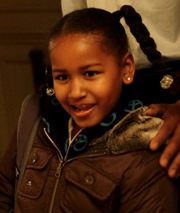

,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_00.jpg,10세 미만,10세 미만,0.252,$0.000057,₩0.086,0.950000,573


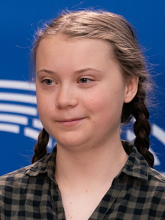

,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_01.jpg,10대,10대,0.235,$0.000061,₩0.091,0.980000,605


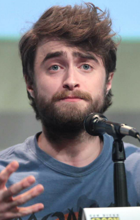

,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_02.png,20대,20대,0.302,$0.000065,₩0.098,0.920000,653


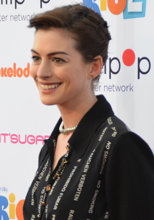

,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_03.jpg,30대,30대,0.259,$0.000068,₩0.102,0.460000,677


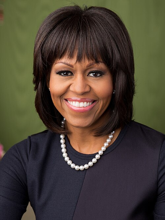

,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_04.jpg,40대,40대,0.356,$0.000061,₩0.091,0.470000,605


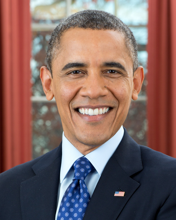

,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_05.png,40대,50대,0.255,$0.000059,₩0.088,0.360000,589


,사진,추정 연령대,참고 연령대,API 시간(초),비용($),비용(원),confidence,입력 토큰
0,sample_00.jpg,10세 미만,10세 미만,0.252,$0.000057,₩0.086,0.950000,573
1,sample_01.jpg,10대,10대,0.235,$0.000061,₩0.091,0.980000,605
2,sample_02.png,20대,20대,0.302,$0.000065,₩0.098,0.920000,653
3,sample_03.jpg,30대,30대,0.259,$0.000068,₩0.102,0.460000,677
4,sample_04.jpg,40대,40대,0.356,$0.000061,₩0.091,0.470000,605
5,sample_05.png,40대,50대,0.255,$0.000059,₩0.088,0.360000,589


In [6]:
rows, answers = [], {}
reference = samples.set_index("file")["reference_group"]
for path in image_paths:
    result, seconds = analyze_image(path)
    answer = result.answers[0].model_dump()
    answers[path.name] = answer
    tokens = result.usage.input_tokens
    usd = tokens / 1_000_000 * USD_PER_MILLION_TOKENS
    row = {
        "사진": path.name,
        "추정 연령대": answer.get("choice", "판단 거절"),
        "참고 연령대": reference.get(path.name, "정보 없음"),
        "API 시간(초)": seconds,
        "비용($)": usd,
        "비용(원)": usd * KRW_PER_USD,
        "confidence": answer.get("confidence"),
        "입력 토큰": tokens,
    }
    rows.append(row)

    # 사진 바로 아래에 추정값·참고값·시간·비용을 함께 보여줍니다.
    with Image.open(path) as original:
        preview = ImageOps.exif_transpose(original).copy()
    preview.thumbnail((180, 220))
    display(preview)
    display(pd.DataFrame([row]).style.format({
        "API 시간(초)": "{:.3f}", "비용($)": "${:.6f}", "비용(원)": "₩{:.3f}",
    }))

# 반올림은 화면에만 적용해 평균 시간과 비용 합계의 정밀도를 유지합니다.
report = pd.DataFrame(rows)
display(report.style.format({
    "API 시간(초)": "{:.3f}", "비용($)": "${:.6f}", "비용(원)": "₩{:.3f}",
}))


## 6. 평균 시간과 비용 출력

첫 요청은 연결 준비 등으로 더 오래 걸릴 수 있습니다. 평균에는 첫 요청을 포함합니다. 비교를 위해 **첫 사진을 제외한 평균**도 별도로 출력합니다. 사진 6장 한 번의 실측이며 서비스 전체의 지연시간 보장은 아닙니다.

비용은 입력 100만 토큰당 $0.10 기본 요금으로 추정합니다. 출력 요금은 없으며 지역 할증·세금은 제외합니다. 환율은 1달러=1,500원으로 가정합니다.

In [7]:
# 전체 평균에는 첫 연결 요청도 포함합니다.
seconds = report["API 시간(초)"]
print(f"사진 수: {len(report)}장")
print(f"평균 API 시간: {seconds.mean():.3f}초")
print(f"최소 / 최대: {seconds.min():.3f}초 / {seconds.max():.3f}초")
print(f"API 시간 합계: {seconds.sum():.3f}초")
if len(report) > 1:
    print(f"첫 사진 제외 평균: {seconds.iloc[1:].mean():.3f}초")

# 기본 입력 토큰 요금으로 추정합니다. 세금·지역 할증은 제외합니다.
usd = report["비용($)"].sum()
krw = report["비용(원)"].sum()
print(f"전체 기본 API 요금 추정: ${usd:.6f} / 약 {krw:.3f}원")
# 표와 상세 응답을 저장하므로 다시 API를 호출하지 않고 결과를 확인할 수 있습니다.
report.to_csv(output / "age_results.csv", index=False, encoding="utf-8-sig")
(output / "answers.json").write_text(json.dumps(answers, ensure_ascii=False, indent=2), encoding="utf-8")


사진 수: 6장
평균 API 시간: 0.277초
최소 / 최대: 0.235초 / 0.356초
API 시간 합계: 1.659초
첫 사진 제외 평균: 0.281초
전체 기본 API 요금 추정: $0.000370 / 약 0.555원


4281

## 내 사진으로 바꾸기

아래처럼 `image_paths`만 바꾸고 **5번부터 다시 실행**하면 됩니다. 본인 사진 또는 사용 동의를 받은 사진을 사용하세요. 참고 연령대가 없는 개인 사진은 결과표의 해당 칸이 비어 있습니다.

```python
image_paths = [Path(r"C:\Users\Playdata\Pictures\my_photo.jpg")]
```

사진의 이름·개인정보는 요청 텍스트에 넣지 않습니다. 출력 폴더에는 분류 결과와 시간만 저장하며, 개인 사진 사본은 저장하지 않습니다.

**참고 자료:** [Decisions 공식 가이드](https://developers.openai.com/api/docs/guides/decisions) · [Python SDK](https://developers.openai.com/api/reference/python/resources/decisions/methods/create) · [샘플 사진 출처와 라이선스](data/age_faces/출처.md)